In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('C:\MAJOR\Dataset\TB_Chest_Radiography_Database'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

C:\MAJOR\Dataset\TB_Chest_Radiography_Database\Normal.metadata.xlsx
C:\MAJOR\Dataset\TB_Chest_Radiography_Database\README.md.txt
C:\MAJOR\Dataset\TB_Chest_Radiography_Database\Tuberculosis.metadata.xlsx
C:\MAJOR\Dataset\TB_Chest_Radiography_Database\Normal\Normal-1.png
C:\MAJOR\Dataset\TB_Chest_Radiography_Database\Normal\Normal-10.png
C:\MAJOR\Dataset\TB_Chest_Radiography_Database\Normal\Normal-100.png
C:\MAJOR\Dataset\TB_Chest_Radiography_Database\Normal\Normal-1000.png
C:\MAJOR\Dataset\TB_Chest_Radiography_Database\Normal\Normal-1001.png
C:\MAJOR\Dataset\TB_Chest_Radiography_Database\Normal\Normal-1008.png
C:\MAJOR\Dataset\TB_Chest_Radiography_Database\Normal\Normal-1009.png
C:\MAJOR\Dataset\TB_Chest_Radiography_Database\Normal\Normal-101.png
C:\MAJOR\Dataset\TB_Chest_Radiography_Database\Normal\Normal-1010.png
C:\MAJOR\Dataset\TB_Chest_Radiography_Database\Normal\Normal-1011.png
C:\MAJOR\Dataset\TB_Chest_Radiography_Database\Normal\Normal-1012.png
C:\MAJOR\Dataset\TB_Chest_Radiogra

In [2]:
!pip install mplcyberpunk
!pip install split-folders

import pathlib, os, random, mplcyberpunk
import splitfolders
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import pandas as pd
import tensorflow as tf
from keras.layers import BatchNormalization, Dense, Dropout, Flatten, MaxPool2D, Conv2D, Activation


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: C:\Users\saite\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: C:\Users\saite\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
base_path = r'C:\MAJOR\Dataset\TB_Chest_Radiography_Database'
base_path = pathlib.Path(base_path)
base_path

WindowsPath('C:/MAJOR/Dataset/TB_Chest_Radiography_Database')

In [4]:
splitfolders.ratio(base_path, output='X_ray_Imgs', seed=123, ratio=(0.7, 0.15, 0.15),
                  group_prefix=None)

Copying files: 3695 files [00:04, 906.26 files/s] 


In [5]:
import os
import pandas as pd

# visualizations libraries
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.image import imread
%matplotlib inline

# tensorflow libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg19 import VGG19
from keras.models import Sequential, Model
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras import optimizers

from tensorflow.keras.utils import load_img
from tensorflow.keras.utils import img_to_array

# model evaluation libraries
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from glob import glob
import os
import numpy as np
import pandas as pd
import random
from skimage.io import imread

import matplotlib.pyplot as plt
%matplotlib inline

from keras.applications.resnet import ResNet50
from keras.applications.resnet import preprocess_input, decode_predictions
from tensorflow.python.keras.models import Sequential
from tensorflow.python.keras.layers import Dense, Flatten, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from keras.applications.mobilenet_v2 import MobileNetV2
from keras.layers import Dense, Dropout, Flatten, BatchNormalization, GlobalMaxPooling2D

In [6]:
print("training data :")
train_datagen= ImageDataGenerator(rescale=1/255, zoom_range=0.3, rotation_range=50, width_shift_range= 0.2, height_shift_range=0.2, shear_range=0.2, 
                                   horizontal_flip=True, fill_mode='nearest', validation_split = 0.2)

train_data = train_datagen.flow_from_directory(base_path, 
                                              target_size= (75,75),
                                              class_mode= "binary",
                                              batch_size=20,
                                              subset= "training"
                                              )

print("\nvalidation data :")
val_datagen= ImageDataGenerator(rescale= 1/255, validation_split= 0.2)

val_data= val_datagen.flow_from_directory(base_path, 
                                              target_size= (75,75),
                                              class_mode= "binary",
                                              batch_size=20,
                                              shuffle= False,
                                              subset= "validation"
                                              )

training data :
Found 2957 images belonging to 2 classes.

validation data :
Found 738 images belonging to 2 classes.


In [7]:
class_names=train_data.class_indices
li=list(class_names)
li

['Normal', 'Tuberculosis']

In [27]:
# inceptionV3 model, with include_top= False we are not using fully connected layer of the inceptionV3 model, instead we
#  will create our own Fully Connected and Output Layer according to our training data
inception_model= InceptionV3(input_shape= (300, 300,3), include_top= False, weights="imagenet")

# Since we are creating our own fully connected layer we need output of the last inception model layer and flatten them 
last_output= inception_model.layers[-1].output

# Flattening the last output
last_output= Flatten()(last_output)

# Our pretrained model
pretrained_model= Model(inception_model.input, last_output)    

In [54]:
# layer 1
x= Dense(units=512, activation="relu")(last_output)
x=Dropout(0.2)(x)

# layer 2
x= Dense(units=128, activation="relu")(x)
x=Dropout(0.2)(x)

# output layer
x= Dense(units=1, activation="sigmoid")(x)

# final model
model= Model(pretrained_model.input, x)



In [55]:
model.summary()


Model: "functional_43"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_564 (Conv2D) │ (None, 149, 149,  │        864 │ input_layer_9[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 149, 149,  │         96 │ conv2d_564[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_564      │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_565 (Conv2D) │ (None, 147, 147,  │      9,216 │ activation_564[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_565[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_565      │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_566 (Conv2D) │ (None, 147, 147,  │     18,432 │ activation_565[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_566[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_566      │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_24    │ (None, 73, 73,    │          0 │ activation_566[0… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_567 (Conv2D) │ (None, 73, 73,    │      5,120 │ max_pooling2d_24… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_567[0][0]  │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_567      │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_568 (Conv2D) │ (None, 71, 71,    │    138,240 │ activation_567[0… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_568[0][0]  │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_568      │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 88,977,953 (339.42 MB)

 Trainable params: 67,175,169 (256.25 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [30]:
print(len(train_data))
print(train_data.samples)
print(train_data.batch_size)


148
2957
20


In [31]:
# Check if batches are being generated correctly
for i in range(5):  # Check first 5 batches
    batch = next(iter(train_data))
    print(f"Batch {i+1} shape: {batch[0].shape}")  # Should print (20, 75, 75, 3) if batch_size=20


Batch 1 shape: (20, 75, 75, 3)
Batch 2 shape: (20, 75, 75, 3)
Batch 3 shape: (20, 75, 75, 3)
Batch 4 shape: (20, 75, 75, 3)
Batch 5 shape: (20, 75, 75, 3)


In [35]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import layers, models, optimizers

# Load pre-trained model
input_shape = (75, 75, 3)
pretrained_model = InceptionV3(input_shape=input_shape, include_top=False, weights="imagenet")

# Freeze pre-trained layers
for layer in pretrained_model.layers:
    layer.trainable = False

# Add classification layers
model = models.Sequential([
    pretrained_model,
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")  # For binary classification
])

# Compile the model
model.compile(loss="binary_crossentropy", optimizer=optimizers.RMSprop(learning_rate=1e-3), metrics=["accuracy"])

# Train the model
history = model.fit(
    train_data,
    steps_per_epoch=len(train_data),  # Ensure all batches are processed
    validation_data=val_data,
    validation_steps=len(val_data),
    epochs=50,
    verbose=1
)

Epoch 1/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 42s 246ms/step - accuracy: 0.7736 - loss: 0.6266 - val_accuracy: 0.7832 - val_loss: 0.6631
Epoch 2/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 34s 231ms/step - accuracy: 0.8509 - loss: 0.3778 - val_accuracy: 0.8428 - val_loss: 0.3955
Epoch 3/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 38s 257ms/step - accuracy: 0.8704 - loss: 0.3281 - val_accuracy: 0.8103 - val_loss: 0.5735
Epoch 4/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 35s 234ms/step - accuracy: 0.8685 - loss: 0.3269 - val_accuracy: 0.8550 - val_loss: 0.3939
Epoch 5/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 34s 228ms/step - accuracy: 0.8911 - loss: 0.3055 - val_accuracy: 0.8293 - val_loss: 0.5139
Epoch 6/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 34s 232ms/step - accuracy: 0.8940 - loss: 0.2956 - val_accuracy: 0.8604 - val_loss: 0.3552
Epoch 7/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 34s 230ms/step - accuracy: 0.8861 - loss: 0.3396 - val_accuracy: 0.8184 - val_loss: 0.5822
Epoch 8/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 35s 235ms/step - accuracy: 0.8900 - loss: 0

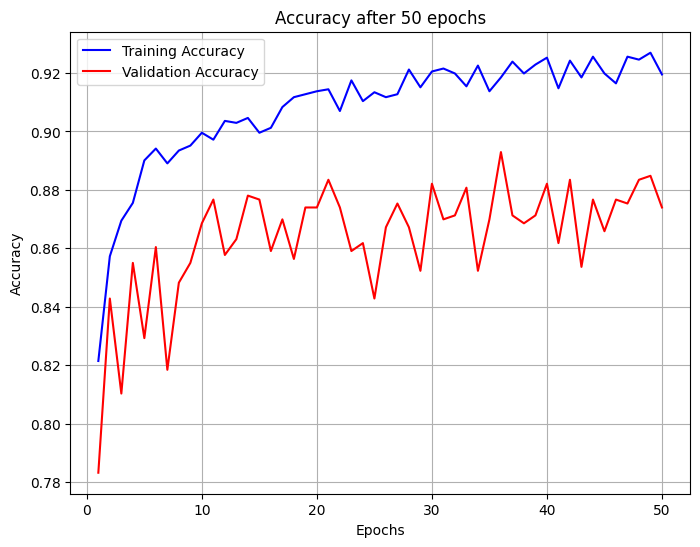

In [36]:
import matplotlib.pyplot as plt

# Extract accuracy and validation accuracy from history
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']

# Plot training and validation accuracy
epochs = range(1, len(training_accuracy) + 1)
plt.figure(figsize=(8, 6))
plt.plot(epochs, training_accuracy, 'b-', label='Training Accuracy')
plt.plot(epochs, validation_accuracy, 'r-', label='Validation Accuracy')
plt.title('Accuracy after 50 epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [38]:
import numpy as np

steps = int(np.ceil(val_data.samples / val_data.batch_size))  # Convert to integer
prediction = model.predict(val_data, steps=steps, verbose=2)
prediction = (prediction > 0.5)  # Convert probabilities to binary class labels


37/37 - 10s - 269ms/step


In [39]:
val_labels=val_data.classes


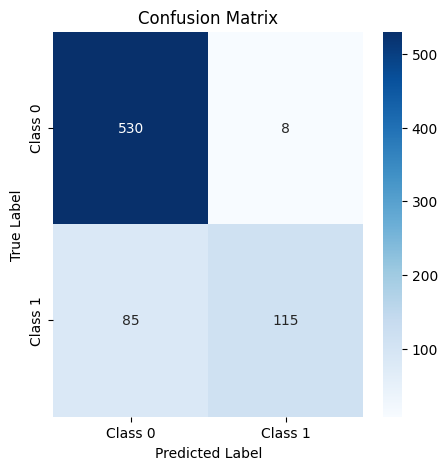

Accuracy Score: 0.8739837398373984
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.99      0.92       538
           1       0.93      0.57      0.71       200

    accuracy                           0.87       738
   macro avg       0.90      0.78      0.82       738
weighted avg       0.88      0.87      0.86       738



In [41]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Compute confusion matrix
cm = confusion_matrix(val_data.classes, prediction)

# Plot confusion matrix using seaborn heatmap
plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Print accuracy and classification report
print("Accuracy Score:", accuracy_score(val_data.classes, prediction))
print("Classification Report:\n", classification_report(val_data.classes, prediction))


In [43]:
from tensorflow.keras.models import load_model
model.save("inception_v3.h5")

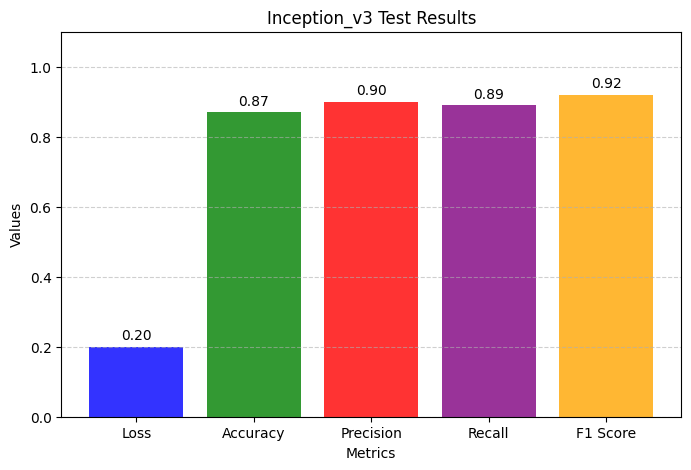

In [1]:
import matplotlib.pyplot as plt

def visualize_lenet_test_results(results):
    """
    Visualize the test results for the LeNet model using a bar chart.
    
    Parameters:
    - results: A list containing values for Loss, Accuracy, Precision, Recall, and F1 Score.
    """
    labels = ['Loss', 'Accuracy', 'Precision', 'Recall', 'F1 Score']
    values = results[:5]  # Ensuring that only the first 5 elements are used for visualization
    # Define bar colors for better visualization
    colors = ['blue', 'green', 'red', 'purple', 'orange']

    # Plotting the bar graph
    plt.figure(figsize=(8, 5))
    plt.bar(labels, values, color=colors, alpha=0.8)
    plt.title('Inception_v3 Test Results')
    plt.xlabel('Metrics')
    plt.ylabel('Values')
    plt.ylim(0, 1.1)  # Assuming metrics range between 0 and 1, adjust as needed
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    
    # Annotating each bar with its value
    for i, value in enumerate(values):
        plt.text(i, value + 0.02, f"{value:.2f}", ha='center', fontsize=10, color='black')

    plt.show()
test_results = [0.2, 0.87, 0.90, 0.89, 0.92]  
# Example usage
visualize_lenet_test_results(test_results)

In [50]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# Load and preprocess the image
def preprocess_image(img_path, target_size=(75, 75)):  # Updated to match model input shape
    img = image.load_img(img_path, target_size=target_size, color_mode="rgb")  # Ensure color_mode is correct
    img_array = image.img_to_array(img)  # Convert image to array
    img_array = img_array / 255.0  # Normalize pixel values
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    return img_array

# Predict function
def predict_tb(img_path, model, threshold=0.5):
    processed_image = preprocess_image(img_path, target_size=model.input_shape[1:3])  # Match model input size
    prediction = model.predict(processed_image)
    predicted_class = int(prediction[0][0] > threshold)  # Convert probability to binary class
    class_label = "Tuberculosis" if predicted_class == 1 else "Normal"
    return prediction[0][0], class_label

# Load the trained model
model = load_model("inception_v3.h5")

# Example usage
img_path = r"C:\MAJOR\Dataset\TB_Chest_Radiography_Database\Normal\Normal-2.png"
probability, label = predict_tb(img_path, model)

print(f"Predicted Probability: {probability:.2f}")
print(f"Prediction: {label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Probability: 0.00
Prediction: Normal


In [9]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# Load and preprocess the image
def preprocess_image(img_path, target_size=(75, 75)):  # Updated to match model input shape
    img = image.load_img(img_path, target_size=target_size, color_mode="rgb")  # Ensure color_mode is correct
    img_array = image.img_to_array(img)  # Convert image to array
    img_array = img_array / 255.0  # Normalize pixel values
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    return img_array

# Predict function
def predict_tb(img_path, model, threshold=0.5):
    processed_image = preprocess_image(img_path, target_size=model.input_shape[1:3])  # Match model input size
    prediction = model.predict(processed_image)
    predicted_class = int(prediction[0][0] > threshold)  # Convert probability to binary class
    class_label = "Tuberculosis" if predicted_class == 1 else "Normal"
    return prediction[0][0], class_label

# Load the trained model
model = load_model("inception_v3.h5")

# Example usage
img_path = r"C:\MAJOR\Dataset\TB_Chest_Radiography_Database\Tuberculosis\Tuberculosis-23.png"
probability, label = predict_tb(img_path, model)

print(f"Predicted Probability: {probability:.2f}")
print(f"Prediction: {label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Probability: 1.00
Prediction: Tuberculosis


In [10]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# Load and preprocess the image
def preprocess_image(img_path, target_size=(75, 75)):  # Updated to match model input shape
    img = image.load_img(img_path, target_size=target_size, color_mode="rgb")  # Ensure color_mode is correct
    img_array = image.img_to_array(img)  # Convert image to array
    img_array = img_array / 255.0  # Normalize pixel values
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    return img_array

# Predict function
def predict_tb(img_path, model, threshold=0.5):
    processed_image = preprocess_image(img_path, target_size=model.input_shape[1:3])  # Match model input size
    prediction = model.predict(processed_image)
    predicted_class = int(prediction[0][0] > threshold)  # Convert probability to binary class
    class_label = "Tuberculosis" if predicted_class == 1 else "Normal"
    return prediction[0][0], class_label

# Load the trained model
model = load_model("inception_v3.h5")

# Example usage
img_path = r"C:\MAJOR\Dataset\TB_Chest_Radiography_Database\Tuberculosis\Tuberculosis-77.png"
probability, label = predict_tb(img_path, model)

print(f"Predicted Probability: {probability:.2f}")
print(f"Prediction: {label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Probability: 0.93
Prediction: Tuberculosis


In [12]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# Load and preprocess the image
def preprocess_image(img_path, target_size=(75, 75)):  # Updated to match model input shape
    img = image.load_img(img_path, target_size=target_size, color_mode="rgb")  # Ensure color_mode is correct
    img_array = image.img_to_array(img)  # Convert image to array
    img_array = img_array / 255.0  # Normalize pixel values
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    return img_array

# Predict function
def predict_tb(img_path, model, threshold=0.5):
    processed_image = preprocess_image(img_path, target_size=model.input_shape[1:3])  # Match model input size
    prediction = model.predict(processed_image)
    predicted_class = int(prediction[0][0] > threshold)  # Convert probability to binary class
    class_label = "Tuberculosis" if predicted_class == 1 else "Normal"
    return prediction[0][0], class_label

# Load the trained model
model = load_model("inception_v3.h5")

# Example usage
img_path = r"C:\MAJOR\Dataset\TB_Chest_Radiography_Database\Tuberculosis\Tuberculosis-75.png"
probability, label = predict_tb(img_path, model)

print(f"Predicted Probability: {probability:.2f}")
print(f"Prediction: {label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted Probability: 1.00
Prediction: Tuberculosis
